In [ ]:
#Importing the libs required

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")
sns.set_style("whitegrid")

In [ ]:
##loading the dataset
df = pd.read_csv("/content/OnlineRetail.csv", encoding="latin1")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [ ]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
486619,577742,22558,CLOTHES PEGS RETROSPOT PACK 24,1,11/21/2011 13:41,1.65,13755.0,United Kingdom
486620,577742,82616C,MIDNIGHT GLAMOUR SCARF KNITTING KIT,1,11/21/2011 13:41,1.25,13755.0,United Kingdom
486621,577742,21731,RED TOADSTOOL LED NIGHT LIGHT,1,11/21/2011 13:41,1.65,13755.0,United Kingdom
486622,577742,22804,PINK HANGING HEART T-LIGHT HOLDER,1,11/21/2011 13:41,2.95,13755.0,United Kingdom
486623,577742,21098,CHRISTMAS TOILET ROLL,1,11/21/20,NaN,NaN,NaN


In [ ]:

#checking dataset size
print("Number of Rows :", df.shape[0])

print("Number of Columns :", df.shape[1])

print("Dataset Shape :", df.shape)

Number of Rows : 486624
Number of Columns : 8
Dataset Shape : (486624, 8)


In [ ]:
#shows coluumns
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [ ]:
#shows data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 486624 entries, 0 to 486623
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    486624 non-null  object 
 1   StockCode    486624 non-null  object 
 2   Description  485214 non-null  object 
 3   Quantity     486624 non-null  int64  
 4   InvoiceDate  486624 non-null  object 
 5   UnitPrice    486623 non-null  float64
 6   CustomerID   367486 non-null  float64
 7   Country      486623 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 29.7+ MB


In [ ]:
#finding missing values
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1410
Quantity,0
InvoiceDate,0
UnitPrice,1
CustomerID,119138
Country,1


In [ ]:
# CustomerID is required for customer segmentation.
# Rows without CustomerID cannot be grouped by customer.
df = df.dropna(subset=["CustomerID"])

# Verify remaining missing values
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [ ]:
# Counting duplicate rows
duplicates = df.duplicated().sum()

print("Duplicate Rows :", duplicates)

# Remove duplicates
df.drop_duplicates(inplace=True)

print("Dataset Shape After Removing Duplicates :", df.shape)

Duplicate Rows : 4439
Dataset Shape After Removing Duplicates : (363047, 8)


In [ ]:
# Calculate total amount for each transaction

df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34


In [ ]:
# Converting InvoiceDate to datetime format

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["InvoiceDate"].dtype

dtype('<M8[ns]')

In [ ]:
# The latest invoice date in the dataset
latest_date = df["InvoiceDate"].max()
reference_date = latest_date + pd.Timedelta(days=1)

print(reference_date)

2011-11-22 13:41:00


In [ ]:
# Find each customer's most recent purchase date
recency = df.groupby("CustomerID")["InvoiceDate"].max().reset_index()

# Calculate the number of days since the last purchase
recency["Recency"] = (reference_date - recency["InvoiceDate"]).dt.days
recency.head()

,CustomerID,InvoiceDate,Recency
0,12346.0,2011-01-18 10:17:00,308
1,12347.0,2011-10-31 12:25:00,22
2,12348.0,2011-09-25 13:13:00,58
3,12349.0,2011-11-21 09:51:00,1
4,12350.0,2011-02-02 16:01:00,292


In [ ]:
# Count the number of unique invoices for each customer
frequency = df.groupby("CustomerID")["InvoiceNo"].nunique().reset_index()

# Rename the column
frequency.columns = ["CustomerID", "Frequency"]
frequency.head()

,CustomerID,Frequency
0,12346.0,2
1,12347.0,6
2,12348.0,4
3,12349.0,1
4,12350.0,1


In [ ]:
# Calculate the total money spent by each customer
monetary = df.groupby("CustomerID")["TotalPrice"].sum().reset_index()

# Rename column
monetary.columns = ["CustomerID", "Monetary"]
monetary.head()

,CustomerID,Monetary
0,12346.0,0.00
1,12347.0,4085.18
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40


In [ ]:
# Merge Recency and Frequency
rfm = pd.merge(recency, frequency, on="CustomerID")

# Merge Monetary
rfm = pd.merge(rfm, monetary, on="CustomerID")
rfm.head()

,CustomerID,InvoiceDate,Recency,Frequency,Monetary
0,12346.0,2011-01-18 10:17:00,308,2,0.00
1,12347.0,2011-10-31 12:25:00,22,6,4085.18
2,12348.0,2011-09-25 13:13:00,58,4,1797.24
3,12349.0,2011-11-21 09:51:00,1,1,1757.55
4,12350.0,2011-02-02 16:01:00,292,1,334.40


In [ ]:
# Estimate Customer Lifetime Value (CLV)
rfm["CLV"] = rfm["Frequency"] * rfm["Monetary"]
rfm.head()

,CustomerID,InvoiceDate,Recency,Frequency,Monetary,CLV
0,12346.0,2011-01-18 10:17:00,308,2,0.00,0.00
1,12347.0,2011-10-31 12:25:00,22,6,4085.18,24511.08
2,12348.0,2011-09-25 13:13:00,58,4,1797.24,7188.96
3,12349.0,2011-11-21 09:51:00,1,1,1757.55,1757.55
4,12350.0,2011-02-02 16:01:00,292,1,334.40,334.40


In [ ]:
rfm.describe()

,CustomerID,InvoiceDate,Recency,Frequency,Monetary,CLV
count,4248.000000,4248,4248.000000,4248.000000,4248.000000,4.248000e+03
mean,15297.721516,2011-08-22 21:42:09.152542208,91.223399,4.773305,1784.014057,4.602147e+04
min,12346.000000,2010-12-01 09:53:00,1.000000,1.000000,-4287.630000,-5.826500e+03
25%,13812.750000,2011-06-27 12:59:30,15.000000,1.000000,283.060000,3.473700e+02
50%,15298.500000,2011-10-05 13:47:00,47.000000,2.000000,619.380000,1.432350e+03
75%,16773.250000,2011-11-07 13:00:15,148.000000,5.000000,1506.685000,7.278465e+03
max,18287.000000,2011-11-21 13:41:00,356.000000,226.000000,257094.120000,2.694578e+07
std,1721.285034,NaN,98.221272,8.658972,7749.633614,6.104078e+05


In [ ]:
# Select the RFM features for clustering
X = rfm[['Recency', 'Frequency', 'Monetary']]
X.head()

,Recency,Frequency,Monetary
0,308,2,0.00
1,22,6,4085.18
2,58,4,1797.24
3,1,1,1757.55
4,292,1,334.40


In [ ]:
# Create the StandardScaler object
scaler = StandardScaler()

# Fit and transform the selected features
X_scaled = scaler.fit_transform(X)

# Display first five rows of standardized data
pd.DataFrame(
    X_scaled,
    columns=['Recency','Frequency','Monetary']
).head()

,Recency,Frequency,Monetary
0,2.207283,-0.320319,-0.230233
1,-0.704853,0.141684,0.296974
2,-0.338290,-0.089317,0.001707
3,-0.918681,-0.435820,-0.003415
4,2.044366,-0.435820,-0.187078


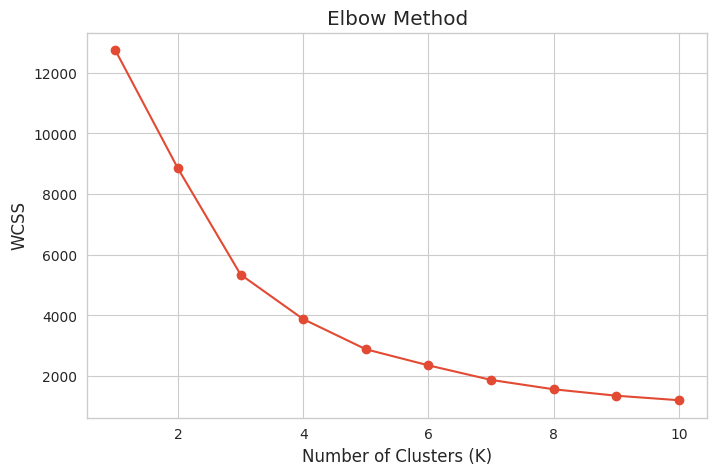

In [ ]:
# Create an empty list to store WCSS values
wcss = []

# Calculate WCSS for different numbers of clusters
for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")

plt.xlabel("Number of Clusters (K)")

plt.ylabel("WCSS")

plt.show()

In [ ]:
# Create the KMeans model
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

# Fit the model and predict clusters
rfm['Cluster'] = kmeans.fit_predict(X_scaled)

# Display first five rows
rfm.head()

,CustomerID,InvoiceDate,Recency,Frequency,Monetary,CLV,Cluster
0,12346.0,2011-01-18 10:17:00,308,2,0.00,0.00,2
1,12347.0,2011-10-31 12:25:00,22,6,4085.18,24511.08,0
2,12348.0,2011-09-25 13:13:00,58,4,1797.24,7188.96,0
3,12349.0,2011-11-21 09:51:00,1,1,1757.55,1757.55,0
4,12350.0,2011-02-02 16:01:00,292,1,334.40,334.40,2


In [ ]:
# COUNT CUSTOMERS PER CLUSTER
rfm['Cluster'].value_counts().sort_index()

,count
Cluster,
0,2994
1,6
2,1133
3,115


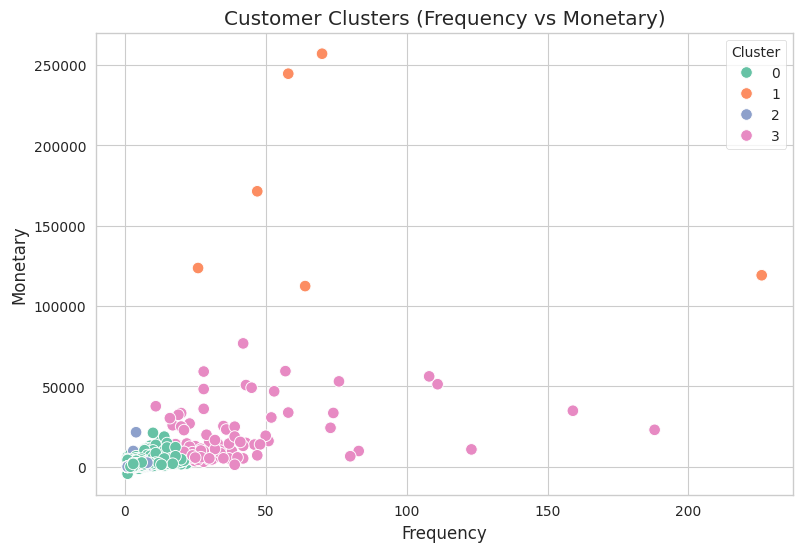

In [ ]:
#scatter plot
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='Set2',
    s=70
)

plt.title("Customer Clusters (Frequency vs Monetary)")

plt.xlabel("Frequency")

plt.ylabel("Monetary")

plt.show()

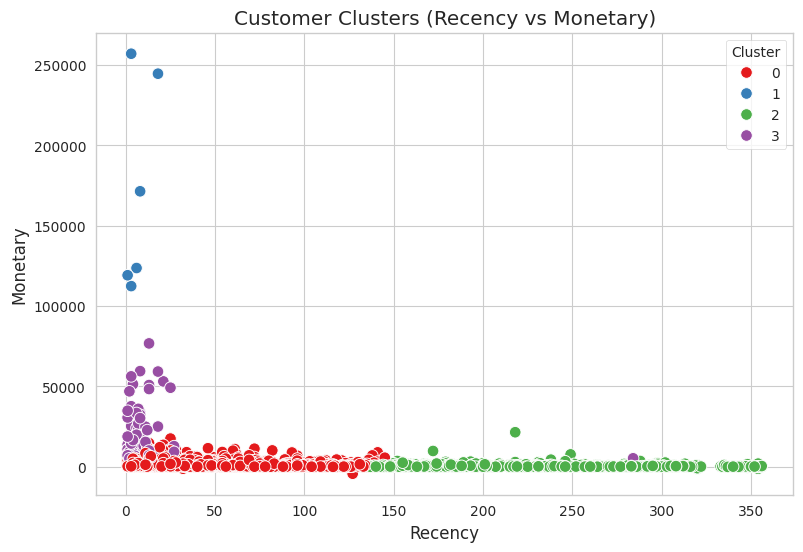

In [ ]:
#most valuable customer
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    palette='Set1',
    s=70
)

plt.title("Customer Clusters (Recency vs Monetary)")

plt.xlabel("Recency")

plt.ylabel("Monetary")

plt.show()

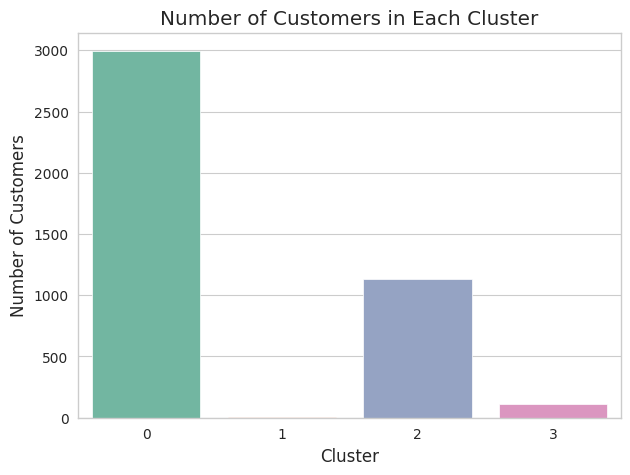

In [ ]:
#summarizes the average characteristics of each customer segment.
plt.figure(figsize=(7,5))

sns.countplot(
    data=rfm,
    x='Cluster',
    hue='Cluster',
    palette='Set2',
    legend=False
)

plt.title("Number of Customers in Each Cluster")

plt.xlabel("Cluster")

plt.ylabel("Number of Customers")

plt.show()

In [ ]:
#shows clusters
print(cluster_profile)

            Recency  Frequency       Monetary
Cluster                                      
0         39.712759   4.510688    1392.164667
1          6.500000  81.833333  171446.793333
2        235.899382   1.811121     452.101519
3         11.339130  36.773913   16255.990609


In [ ]:
# Final dataset
rfm.to_csv("Customer_Segmentation.csv", index=False)

print("Customer segmentation dataset saved successfully!")

Customer segmentation dataset saved successfully!
